In [ ]:
# 실속파, 장거리파, 패밀리 / 캠핑파, 성격 급한파 (운전자 성향별 추천)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 파일 불러오기
ev = pd.read_csv('/content/sample_data/project/electric_vehicles_spec_2025.csv.csv')

# brand 이름을 인덱스로 지정하기
ndf = ev.set_index(['brand'])

# 'Audi', 'BMW', 'Hyundai', 'Kia', 'Mercedes-Benz', 'Porsche', 'Tesla', 'Volkswagen', 'Volvo' 행, 'model', 'battery_capacity_kWh', 'efficiency_wh_per_km', 'range_km' 열 선택
df = ndf.loc[['Audi', 'BMW', 'Hyundai', 'Kia', 'Mercedes-Benz', 'Porsche', 'Tesla', 'Volkswagen', 'Volvo'], ['model', 'battery_capacity_kWh', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l']]
# print(df)

# 전비 = 주행거리 / 배터리용량
df['EV_efficiency'] = df['range_km'] / df['battery_capacity_kWh']
# print(df)

# 실속파 : EV_efficiency (전비) 가 높을수록 상위권
df['실속파'] = df['EV_efficiency'].rank(ascending = False).astype('int')
display(df)

# 장거리파 : range_km 가 높을수록 상위권
df['장거리파'] = df['range_km'].rank(ascending = False).astype('int')
df

# cargo_volume_l (트렁크 용량) 열에서 문자가 포함된 값 숫자로 바꿔주기 (coerce는 숫자로 변환할 수 없는 값 NaN으로 표시)
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors = 'coerce')

# towing_capacity_kg (견인 능력) 열에서 문자가 포함된 값 숫자로 바꿔주기 (coerce는 숫자로 변환할 수 없는 값 NaN으로 표시)
df['towing_capacity_kg'] = pd.to_numeric(df['towing_capacity_kg'], errors = 'coerce')

# cargo_volume_l (트렁크 용량) + towing_capacity_kg (견인 능력)
df['cargo_towing_sum'] = df['cargo_volume_l'].fillna(0) + df['towing_capacity_kg'].fillna(0)

# 패밀리 / 캠핑파 : cargo_volume_l (트렁크 용량), towing_capacity_kg (견인 능력) 합산이 높을 수록 상위권 (method (동점자 처리) = 'dense'는 공동 1위면 다 1위, 그 다음은 2위로 표시)
df['패밀리 / 캠핑파'] = df['cargo_towing_sum'].rank(ascending = False, method = 'dense').astype('int')
df

# 인덱스를 초기화해서 숫자로 인덱스를 만든다.
df = df.reset_index()

# 성격 급한파 : fast_charging_power_kw_dc (급속 충전 출력) 값은 높을수록, acceleration_0_100_s (제로백) 값은 낮을수록 상위권
# 급속 충전 출력을 기준으로 정렬하고, 급속 충전 출력값이 똑같은 데이터들끼리만 모아서 제로백 기준으로 다시 정렬하는 함수 (sort_values())
df_sorted = df.sort_values(by = ['fast_charging_power_kw_dc', 'acceleration_0_100_s'], ascending = [False, True])
df_sorted['성격 급한파'] = range(1, len(df_sorted) + 1)
# print(df_sorted)

# 원래 df에 '인덱스'를 기준으로 순위 값을 가져와서 넣는 것 (map : df_sorted는 순위를 매기면서 순서가 섞여 있지만 map()을 사용하면 원래 df의 인덱스 값으로 정렬해 준다.)
df['성격 급한파'] = df.index.map(df_sorted['성격 급한파'])
df

df = df.set_index(['brand', 'model'])
df

,model,battery_capacity_kWh,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,cargo_volume_l,EV_efficiency,실속파
brand,,,,,,,,,
Audi,A6 Avant e-tron,75.8,465,6.0,150.0,2100.0,502,6.134565,25
Audi,A6 Avant e-tron performance,94.9,575,5.4,200.0,2100.0,502,6.059009,32
Audi,A6 Avant e-tron quattro,94.9,560,4.5,200.0,2100.0,502,5.900948,53
Audi,A6 Sportback e-tron,75.8,495,6.0,150.0,2100.0,502,6.530343,9
Audi,A6 Sportback e-tron performance,94.9,610,5.4,200.0,2100.0,502,6.427819,13
...,...,...,...,...,...,...,...,...,...
Volvo,EX40 Twin Motor (MY26),79.0,385,4.8,125.0,1800.0,410,4.873418,159
Volvo,EX40 Twin Motor Performance (MY26),79.0,385,4.6,125.0,1800.0,410,4.873418,159
Volvo,EX90 Single Motor (MY24-26),100.0,460,8.4,140.0,1200.0,310,4.600000,174


battery_capacity_kWh  range_km  \
brand model                                                                   
Audi  A6 Avant e-tron                                        75.8       465   
      A6 Avant e-tron performance                            94.9       575   
      A6 Avant e-tron quattro                                94.9       560   
      A6 Sportback e-tron                                    75.8       495   
      A6 Sportback e-tron performance                        94.9       610   
...                                                           ...       ...   
Volvo EX40 Twin Motor (MY26)                                 79.0       385   
      EX40 Twin Motor Performance (MY26)                     79.0       385   
      EX90 Single Motor (MY24-26)                           100.0       460   
      EX90 Twin Motor (MY24-26)                             107.0       470   
      EX90 Twin Motor Performance (MY24-26)                 107.0       455   

                                             acceleration_0_100_s  \
brand model                                                         
Audi  A6 Avant e-tron                                         6.0   
      A6 Avant e-tron performance                             5.4   
      A6 Avant e-tron quattro                                 4.5   
      A6 Sportback e-tron                                     6.0   
      A6 Sportback e-tron performance                         5.4   
...                                                           ...   
Volvo EX40 Twin Motor (MY26)                                  4.8   
      EX40 Twin Motor Performance (MY26)                      4.6   
      EX90 Single Motor (MY24-26)                             8.4   
      EX90 Twin Motor (MY24-26)                               5.9   
      EX90 Twin Motor Performance (MY24-26)                   4.9   

                                             fast_charging_power_kw_dc  \
brand model                                                              
Audi  A6 Avant e-tron                                            150.0   
      A6 Avant e-tron performance                                200.0   
      A6 Avant e-tron quattro                                    200.0   
      A6 Sportback e-tron                                        150.0   
      A6 Sportback e-tron performance                            200.0   
...                                                                ...   
Volvo EX40 Twin Motor (MY26)                                     125.0   
      EX40 Twin Motor Performance (MY26)                         125.0   
      EX90 Single Motor (MY24-26)                                140.0   
      EX90 Twin Motor (MY24-26)                                  150.0   
      EX90 Twin Motor Performance (MY24-26)                      150.0   

                                             towing_capacity_kg  \
brand model                                                       
Audi  A6 Avant e-tron                                    2100.0   
      A6 Avant e-tron performance                        2100.0   
      A6 Avant e-tron quattro                            2100.0   
      A6 Sportback e-tron                                2100.0   
      A6 Sportback e-tron performance                    2100.0   
...                                                         ...   
Volvo EX40 Twin Motor (MY26)                             1800.0   
      EX40 Twin Motor Performance (MY26)                 1800.0   
      EX90 Single Motor (MY24-26)                        1200.0   
      EX90 Twin Motor (MY24-26)                          2200.0   
      EX90 Twin Motor Performance (MY24-26)              2200.0   

                                             cargo_volume_l  EV_efficiency  \
brand model                                                                  
Audi  A6 Avant e-tron                                 502.0       6.134565   
      A6 Avant e-tron performance                 

/tmp/ipython-input-910069970.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='EV_efficiency', y= 'model', data=top_10_practical, palette='viridis')


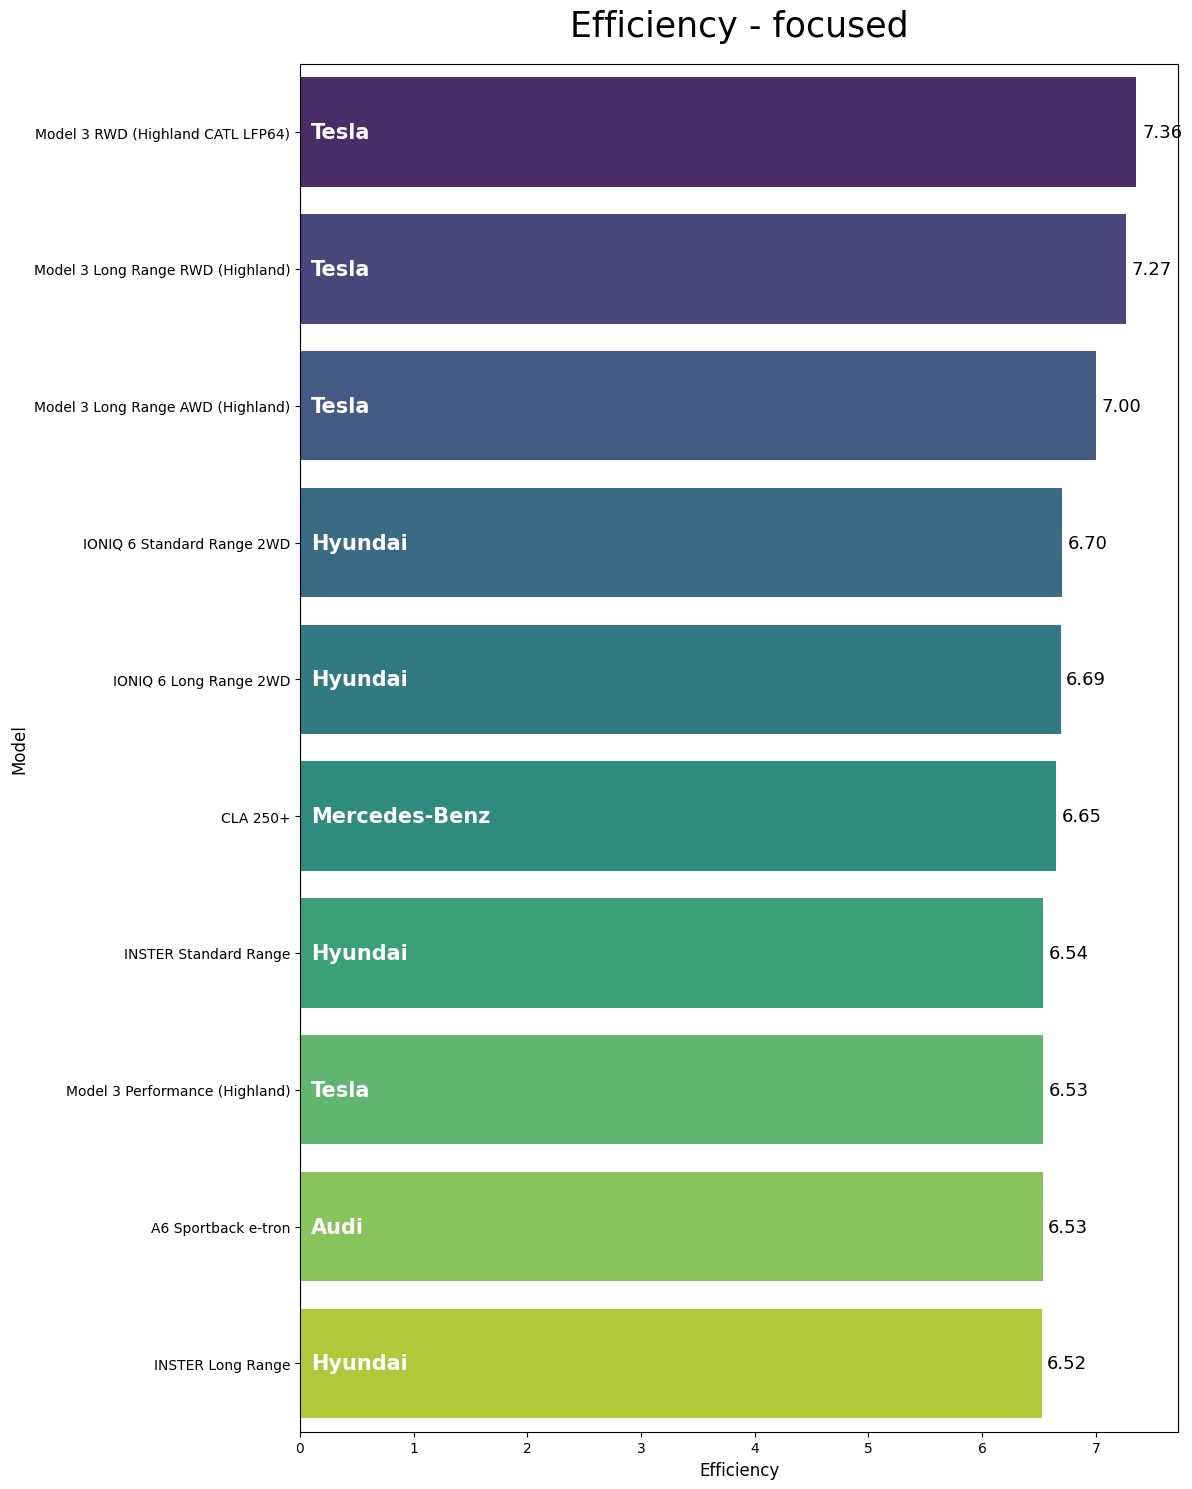

In [ ]:
# 실속파

import matplotlib.pyplot as plt
import seaborn as sns

# 실속파 상위 10위 모델 추출 및 전비 기준 정렬
top_10_practical = df.sort_values(by='실속파').head(10).reset_index()

# 가로 막대 그래프 - 모델명이 길기 때문
plt.figure(figsize=(12, 15))

# Seaborn의 컬러 팔레트를 사용하면 순위별로 색상 변화를 줄 수 있다.
# 'viridis'나 'mako' 같은 팔레트를 쓰면 상위권일수록 진하게 표현된다.
sns.barplot(x='EV_efficiency', y= 'model', data=top_10_practical, palette='viridis')

plt.title('Efficiency - focused', fontsize= 25, pad=20)
plt.xlabel('Efficiency', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 각 막대에 텍스트 추가
for i, row in top_10_practical.iterrows():
    # 막대 끝에 전비 값 표시 (x축 기준으로 간격 띄우고 싶으면 0.05보다 숫자 높이면 된다.)
    plt.text(row['EV_efficiency'] + 0.05, i, f"{row['EV_efficiency']:.2f}", va='center', fontsize= 13, color='black')

    # 막대 시작 부분에 브랜드명 표시
    # x 좌표를 0.1 정도로 주면 막대 왼쪽 안쪽에 글자가 들어간다.
    plt.text(0.1, i, row['brand'], va='center', fontsize= 15, color='white', fontweight='bold')

# 그래프 겹침 방지, 긴 텍스트 보호, 깔끔한 여백 관리
plt.tight_layout()
plt.show()

/tmp/ipython-input-4088764444.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='range_km', y= 'model', data=top_10_practical, palette='mako')


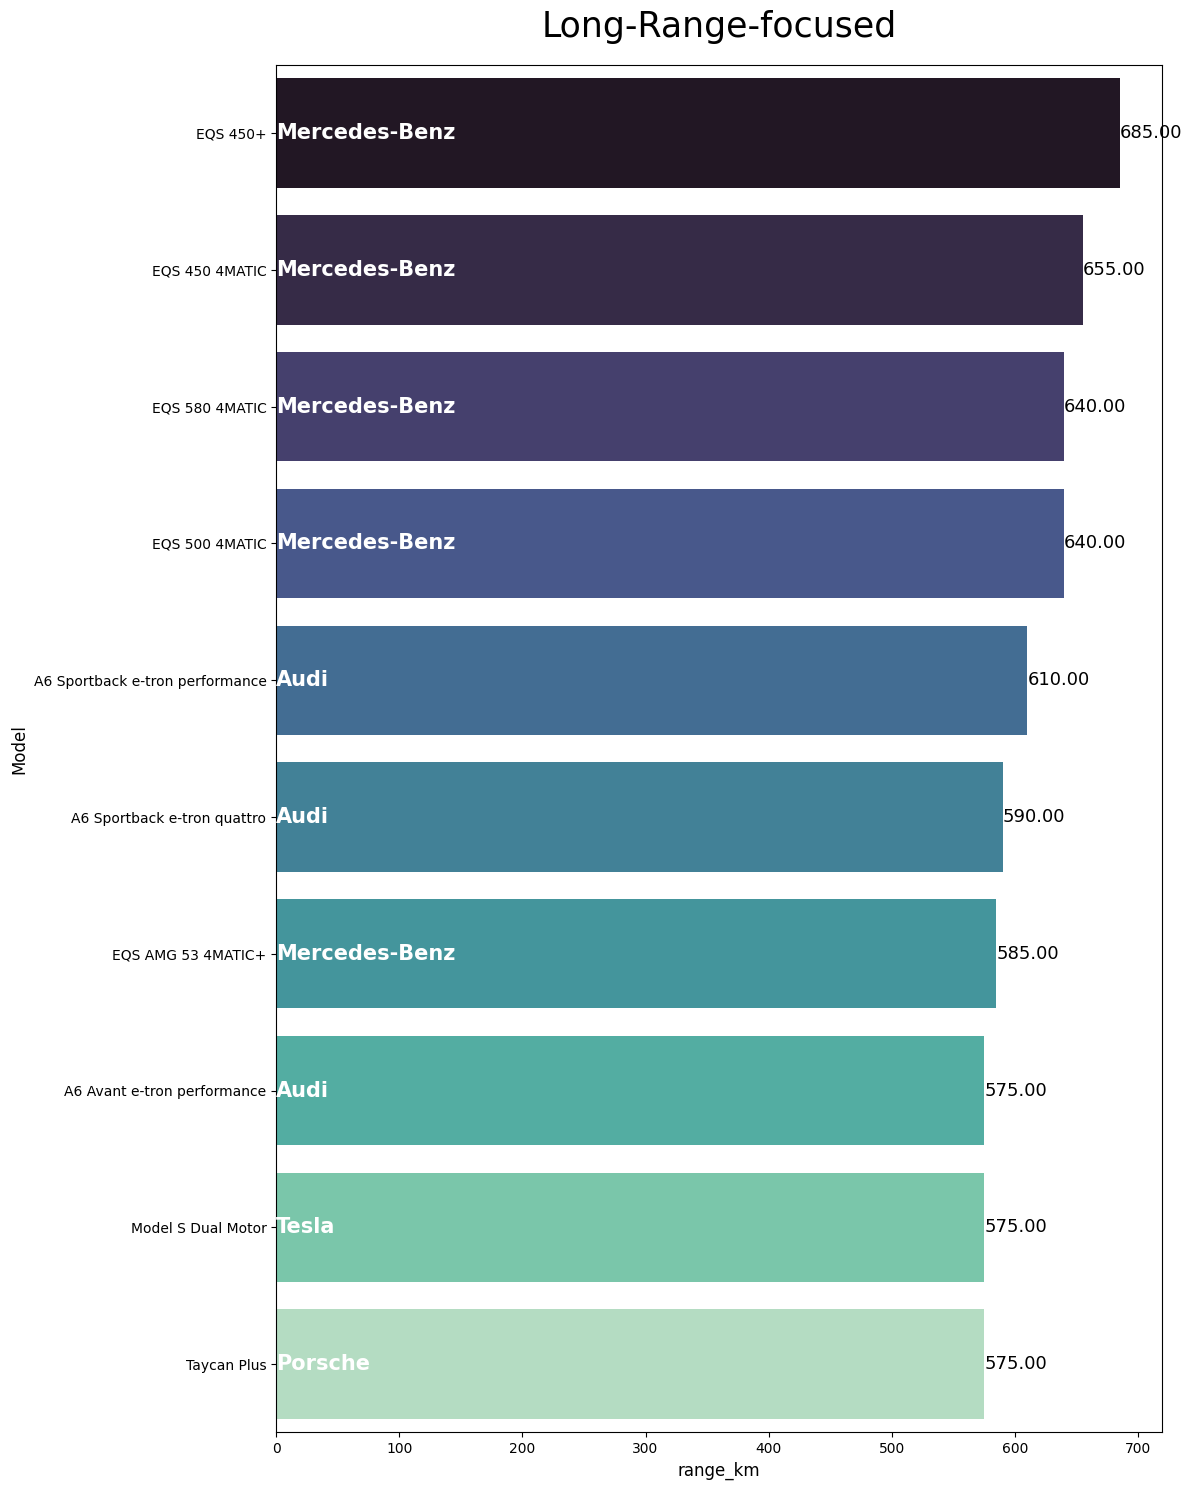

In [ ]:
# 장거리파

import matplotlib.pyplot as plt
import seaborn as sns

# 장거리파 상위 10위 모델 추출 및 전비 기준 정렬
top_10_practical = df.sort_values(by='장거리파').head(10).reset_index()

# 가로 막대 그래프 - 모델명이 길기 때문
plt.figure(figsize=(12, 15))

# Seaborn의 컬러 팔레트를 사용하면 순위별로 색상 변화를 줄 수 있다.
# 'viridis'나 'mako' 같은 팔레트를 쓰면 상위권일수록 진하게 표현된다.
sns.barplot(x='range_km', y= 'model', data=top_10_practical, palette='mako')

plt.title('Long-Range-focused', fontsize= 25, pad=20)
plt.xlabel('range_km', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 각 막대에 텍스트 추가
for i, row in top_10_practical.iterrows():
    # 막대 끝에 주행거리 값 표시
    plt.text(row['range_km'] + 0.05, i, f"{row['range_km']:.2f}", va='center', fontsize= 13, color='black')

    # 막대 시작 부분에 브랜드명 표시
    # x 좌표를 0.1 정도로 하면 막대 왼쪽 안쪽에 글자가 들어간다.
    plt.text(0.1, i, row['brand'], va='center', fontsize= 15, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-237576985.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cargo_towing_sum', y= 'model', data=top_10_practical, palette='crest')


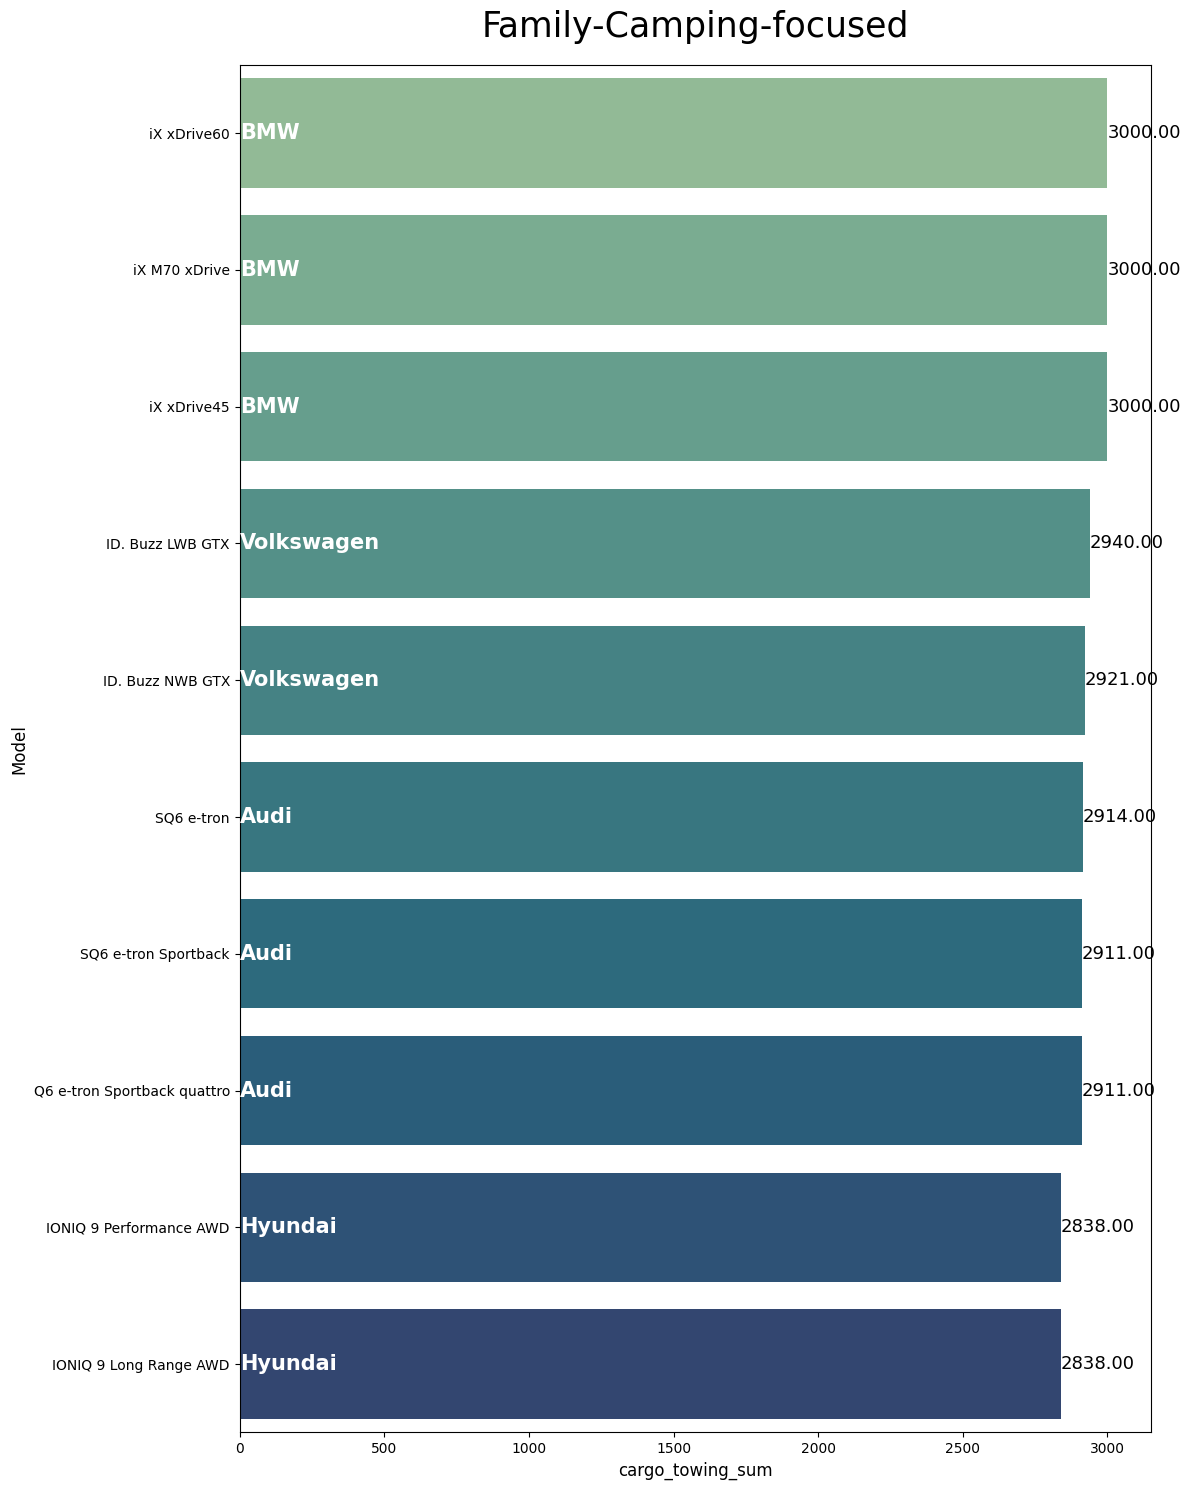

In [ ]:
# 패밀리 / 캠핑파

import matplotlib.pyplot as plt
import seaborn as sns

# 패밀리 / 캠핑파 상위 10위 모델 추출 및 전비 기준 정렬
top_10_practical = df.sort_values(by='패밀리 / 캠핑파').head(10).reset_index()

# 가로 막대 그래프 - 모델명이 길기 때문
plt.figure(figsize=(12, 15))

# Seaborn의 컬러 팔레트를 사용하면 순위별로 색상 변화를 줄 수 있다.
sns.barplot(x='cargo_towing_sum', y= 'model', data=top_10_practical, palette='crest')

plt.title('Family-Camping-focused', fontsize= 25, pad=20)
plt.xlabel('cargo_towing_sum', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 각 막대에 텍스트 추가
for i, row in top_10_practical.iterrows():
    # 막대 끝에 트렁크 용량, 견인 능력 값 표시
    plt.text(row['cargo_towing_sum'] + 0.05, i, f"{row['cargo_towing_sum']:.2f}", va='center', fontsize= 13, color='black')

    # 막대 시작 부분에 브랜드명 표시
    # x 좌표를 0.1 정도로 하면 막대 왼쪽 안쪽에 글자가 들어간다.
    plt.text(0.1, i, row['brand'], va='center', fontsize= 15, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-824785242.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fast_charging_power_kw_dc', y='model', data=top_10_fast, ax=ax1, palette='flare', alpha=0.8)


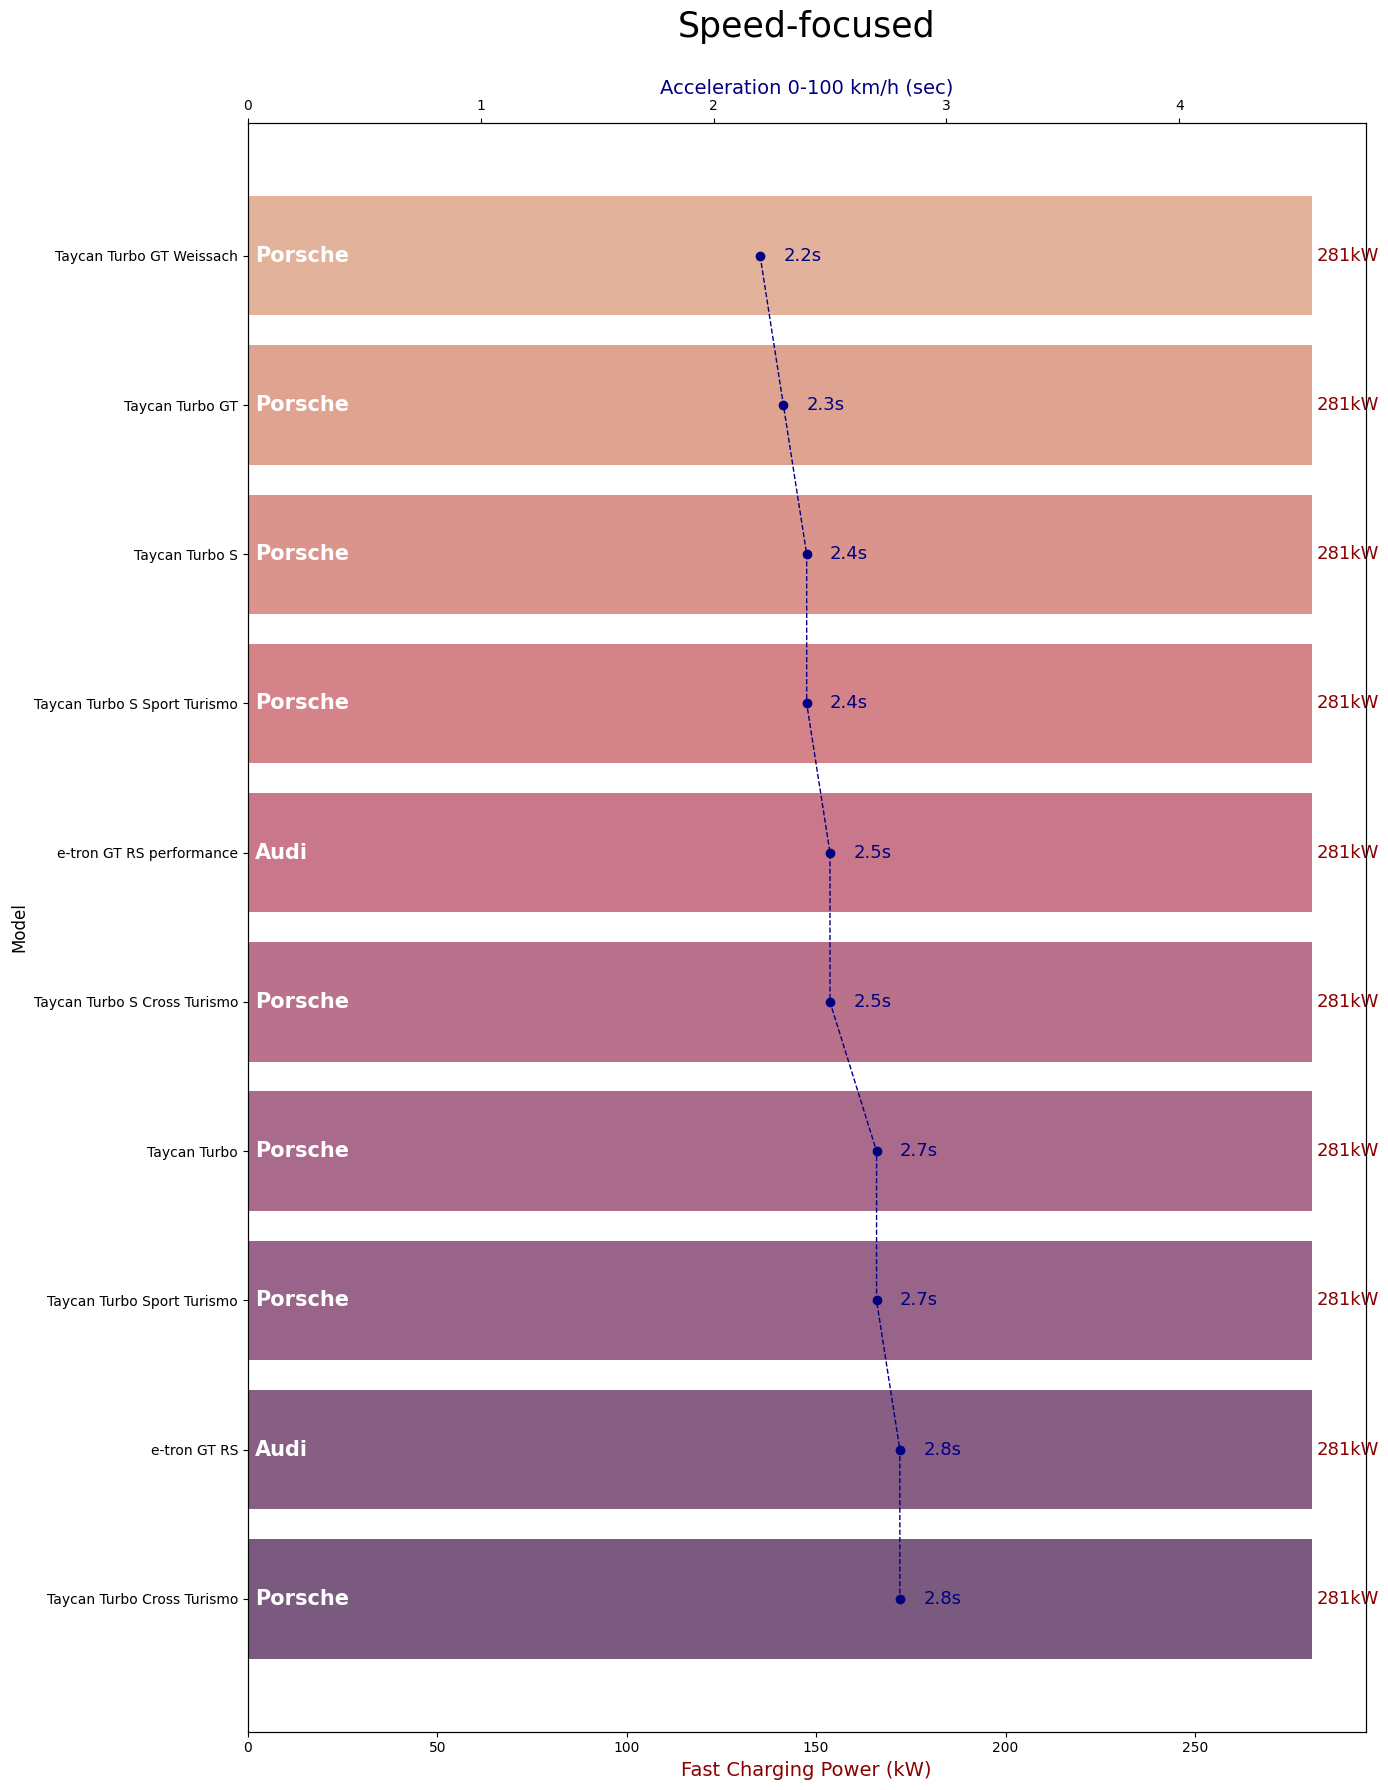

In [ ]:
# 성격 급한파
# 막대 그래프 (급속 충전 출력), 꺾은선 그래프 (제로백) - 충전은 얼마나 빠른데 제로백은 얼마나 짧은가?

import matplotlib.pyplot as plt
import seaborn as sns

# '성격 급한파' 상위 10위 모델 추출 및 순위대로 정렬
top_10_fast = df.sort_values(by='성격 급한파').head(10).reset_index()

# 그래프 설정
fig, ax1 = plt.subplots(figsize=(14, 18))
ax2 = ax1.twiny() # x축을 하나 더 생성 (위쪽 x축)

# 1. 메인 막대 그래프: 급속 충전 출력 (fast_charging_power_kw_dc) (alpha는 투명도 조절하는 기능)
sns.barplot(x='fast_charging_power_kw_dc', y='model', data=top_10_fast, ax=ax1, palette='flare', alpha=0.8)

# 2. 꺾은선 그래프: 제로백 (acceleration_0_100_s)
ax2.plot(top_10_fast['acceleration_0_100_s'], top_10_fast['model'], color='navy', marker='o', linestyle='--', linewidth=1, label='0-100km/h (s)')

ax1.set_title('Speed-focused', fontsize= 25, pad=30)
ax1.set_xlabel('Fast Charging Power (kW)', fontsize=14, color='darkred')
ax2.set_xlabel('Acceleration 0-100 km/h (sec)', fontsize=14, color='navy')
ax1.set_ylabel('Model', fontsize=12)

# 각 막대 안에 브랜드명과 수치 표시
for i, row in top_10_fast.iterrows():
    # 브랜드명 (막대 왼쪽 안쪽)
    ax1.text(2, i, row['brand'], va='center', fontsize= 15, color='white', fontweight='bold')

    # 충전 속도 값 (막대 끝)
    ax1.text(row['fast_charging_power_kw_dc'] + 1, i, f"{row['fast_charging_power_kw_dc']:.0f}kW", va='center', fontsize= 13, color='darkred')

    # 제로백 값 (꺾은선 그래프 점 옆)
    ax2.text(row['acceleration_0_100_s'] + 0.1, i, f"{row['acceleration_0_100_s']:.1f}s", va='center', fontsize= 13, color='navy')

# 제로백은 낮을수록 좋으므로, 최대 제로백 값을 기준으로 공간을 확보해준다.
ax2.set_xlim(0, top_10_fast['acceleration_0_100_s'].max() + 2)

plt.tight_layout()
plt.show()